In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv("../data/processed/train.csv")
test = pd.read_csv("../data/processed/test.csv")

In [3]:
x_train = train.drop(columns=["NObeyesdad"])
y_train = train["NObeyesdad"]
x_test = test.drop(columns=["NObeyesdad"])
y_test = test["NObeyesdad"]

# Baseline RF model performance

In [4]:
from sklearnex import patch_sklearn
patch_sklearn()

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [5]:
from joblib import load

rf_model = load('../models/random_forest_model.pkl')

y_train_pred = rf_model.predict(x_train)
y_test_pred = rf_model.predict(x_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:}")
print(f"Testing Accuracy:  {test_accuracy:}")

Training Accuracy: 1.0
Testing Accuracy:  0.9479905437352246


# Refining Existing RF Model

In [5]:
param_grid = {
    'n_estimators': [250, 300, 350, 400],
    'max_depth': [20, 25, 30, None],
    'min_samples_split': [3, 4, 5, 6],
    'min_samples_leaf': [2, 3, 5],
    'max_features': [0.5, 0.6, 0.7],
    'bootstrap': [True, False],
}


rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

grid_search.fit(x_train, y_train)

print("Best Parameters Found:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_

# joblib.dump(best_rf_model, "../models/random_forest_best_model.pkl")

y_train_pred_rf = best_rf_model.predict(x_train)
y_test_pred_rf = best_rf_model.predict(x_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_rf))

Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
Best Parameters Found: {'bootstrap': False, 'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 350}
Training Accuracy: 1.0
Testing Accuracy: 0.9527186761229315


In [6]:
param_grid = {
    'n_estimators': [300, 400],
    'max_depth': [12, 15, 18],
    'min_samples_leaf': [2, 3, 4],
    'max_features': [0.45, 0.5],
    'bootstrap': [False],
    'max_samples': [None],
    'criterion': ['gini', 'entropy']
}

rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

grid_search.fit(x_train, y_train)

print("Best Parameters Found:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_

# joblib.dump(best_rf_model, "../models/random_forest_best_model.pkl")

y_train_pred_rf = best_rf_model.predict(x_train)
y_test_pred_rf = best_rf_model.predict(x_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_rf))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters Found: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 15, 'max_features': 0.5, 'max_samples': None, 'min_samples_leaf': 2, 'n_estimators': 300}
Training Accuracy: 1.0
Testing Accuracy: 0.9598108747044918


In [6]:
param_grid = {
    'n_estimators': [250, 300, 350, 400],
    'max_depth': [13, 14, 15, 16, 17],
    'min_samples_leaf': [1, 2],
    'max_features': [0.45, 0.5, 0.55],
    'criterion': ['entropy'],
    'bootstrap': [False]
}

rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

grid_search.fit(x_train, y_train)

print("Best Parameters Found:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_


# joblib.dump(best_rf_model, "../models/random_forest_best_model.pkl")

y_train_pred_rf = best_rf_model.predict(x_train)
y_test_pred_rf = best_rf_model.predict(x_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_rf))

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Parameters Found: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 13, 'max_features': 0.55, 'min_samples_leaf': 1, 'n_estimators': 350}
Training Accuracy: 1.0
Testing Accuracy: 0.9598108747044918



Detailed TEST Accuracy Report for Random Forest (Tuned Model):

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        54
           1       0.85      0.97      0.90        58
           2       0.96      0.97      0.96        70
           3       1.00      0.98      0.99        60
           4       1.00      0.98      0.99        65
           5       0.95      0.90      0.92        58
           6       0.98      0.98      0.98        58

    accuracy                           0.96       423
   macro avg       0.96      0.96      0.96       423
weighted avg       0.96      0.96      0.96       423



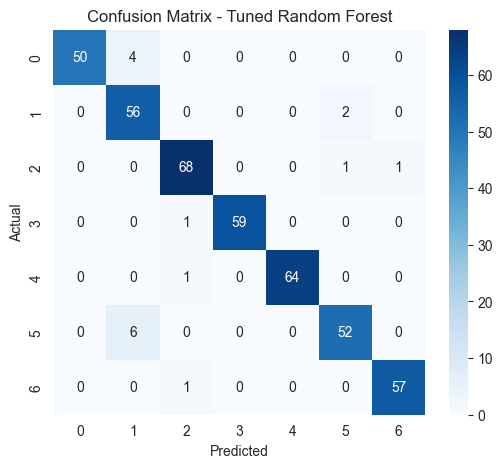

In [7]:
print("\nDetailed TEST Accuracy Report for Random Forest (Tuned Model):\n")
print(classification_report(y_test, y_test_pred_rf))

cm_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Tuned Random Forest')
#plt.savefig('../results/accuracy_figures/confusion_matrices/Tuned-RF Confusion Matrix.png', dpi=300)
plt.show()

# Testing XGBoost

In [8]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=350,
    max_depth=13,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False
)

xgb_model.fit(x_train, y_train)

# Save model
# joblib.dump(xgb_model, "../models/xgboost_model.pkl")

C:\Users\ratul\PycharmProjects\DWDM_EPJ\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:25:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [9]:
y_train_pred_xgb = xgb_model.predict(x_train)
y_test_pred_xgb = xgb_model.predict(x_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_xgb))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_xgb))

Training Accuracy: 1.0
Testing Accuracy: 0.9574468085106383



Detailed TEST Accuracy Report for XGBoost:

              precision    recall  f1-score   support

           0       0.98      0.91      0.94        54
           1       0.86      0.93      0.89        58
           2       0.99      0.99      0.99        70
           3       0.98      1.00      0.99        60
           4       1.00      0.98      0.99        65
           5       0.91      0.91      0.91        58
           6       0.98      0.97      0.97        58

    accuracy                           0.96       423
   macro avg       0.96      0.96      0.96       423
weighted avg       0.96      0.96      0.96       423



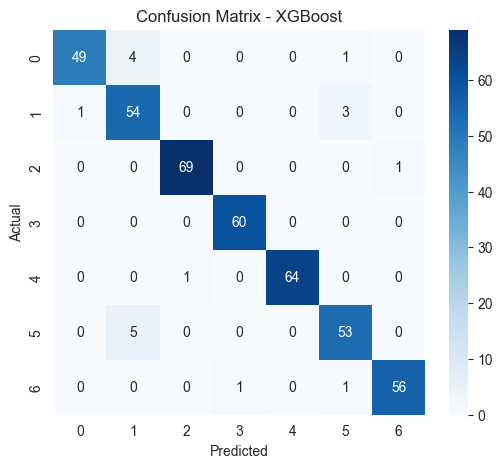

In [10]:
print("\nDetailed TEST Accuracy Report for XGBoost:\n")
print(classification_report(y_test, y_test_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - XGBoost')
#plt.savefig('../results/accuracy_figures/confusion_matrices/XGBoost Confusion Matrix.png', dpi=300)
plt.show()

# Testing LightGBM

In [11]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier()

lgbm_model.fit(x_train, y_train)

# Save model
# joblib.dump(lgbm_model, "../models/lightgbm_model.pkl")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000693 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1808
[LightGBM] [Info] Number of data points in the train set: 1688, number of used features: 15
[LightGBM] [Info] Start training from score -2.046805
[LightGBM] [Info] Start training from score -1.997578
[LightGBM] [Info] Start training from score -1.792945
[LightGBM] [Info] Start training from score -1.963240
[LightGBM] [Info] Start training from score -1.874472
[LightGBM] [Info] Start training from score -1.984562
[LightGBM] [Info] Start training from score -1.984562
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [12]:
y_train_pred_lgbm = lgbm_model.predict(x_train)
y_test_pred_lgbm = lgbm_model.predict(x_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_lgbm))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_lgbm))

Training Accuracy: 1.0
Testing Accuracy: 0.966903073286052



Detailed TEST Accuracy Report for LightGBM:

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        54
           1       0.88      1.00      0.94        58
           2       0.99      0.94      0.96        70
           3       0.98      0.98      0.98        60
           4       1.00      0.98      0.99        65
           5       0.98      0.91      0.95        58
           6       0.95      1.00      0.97        58

    accuracy                           0.97       423
   macro avg       0.97      0.97      0.97       423
weighted avg       0.97      0.97      0.97       423



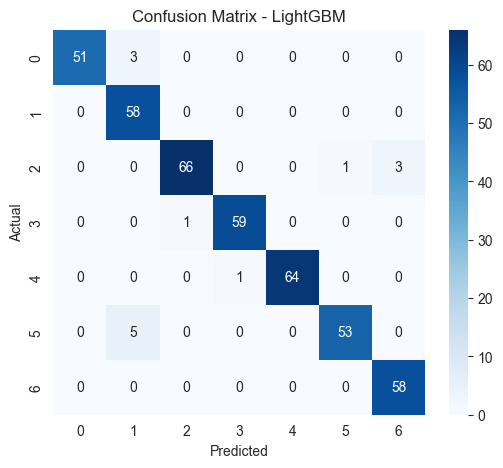

In [13]:
print("\nDetailed TEST Accuracy Report for LightGBM:\n")
print(classification_report(y_test, y_test_pred_lgbm))

cm_lgbm = confusion_matrix(y_test, y_test_pred_lgbm)
plt.figure(figsize=(6,5))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - LightGBM')
#plt.savefig('../results/accuracy_figures/confusion_matrices/LightGBM Confusion Matrix.png', dpi=300)
plt.show()

# VotingClassifier

In [14]:
from sklearn.ensemble import VotingClassifier

rf_model = RandomForestClassifier(
    n_estimators=350,
    max_depth=13,
    max_features=0.55,
    min_samples_leaf=1,
    bootstrap=False,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=350,
    max_depth=13,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False
)

lgbm_model = LGBMClassifier()

rf_model.fit(x_train, y_train)
xgb_model.fit(x_train, y_train)
lgbm_model.fit(x_train, y_train)

voting_clf = VotingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model),('lgbm', lgbm_model)],
    voting='soft',       # average predicted probabilities
)


voting_clf.fit(x_train, y_train)

# Save model
joblib.dump(voting_clf, "../models/voting_classifier_(BEST_MODEL).pkl")

C:\Users\ratul\PycharmProjects\DWDM_EPJ\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:25:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000247 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1808
[LightGBM] [Info] Number of data points in the train set: 1688, number of used features: 15
[LightGBM] [Info] Start training from score -2.046805
[LightGBM] [Info] Start training from score -1.997578
[LightGBM] [Info] Start training from score -1.792945
[LightGBM] [Info] Start training from score -1.963240
[LightGBM] [Info] Start training from score -1.874472
[LightGBM] [Info] Start training from score -1.984562
[LightGBM] [Info] Start training from score -1.984562
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

C:\Users\ratul\PycharmProjects\DWDM_EPJ\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:25:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1808
[LightGBM] [Info] Number of data points in the train set: 1688, number of used features: 15
[LightGBM] [Info] Start training from score -2.046805
[LightGBM] [Info] Start training from score -1.997578
[LightGBM] [Info] Start training from score -1.792945
[LightGBM] [Info] Start training from score -1.963240
[LightGBM] [Info] Start training from score -1.874472
[LightGBM] [Info] Start training from score -1.984562
[LightGBM] [Info] Start training from score -1.984562
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

['../models/voting_classifier_(BEST_MODEL).pkl']

In [15]:
y_train_pred_v = voting_clf.predict(x_train)
y_test_pred_v = voting_clf.predict(x_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_v))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_v))

Training Accuracy: 1.0
Testing Accuracy: 0.9692671394799054



Detailed TEST Accuracy Report for Voting Classifier:

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        54
           1       0.88      0.98      0.93        58
           2       0.99      0.97      0.98        70
           3       0.98      0.98      0.98        60
           4       1.00      0.98      0.99        65
           5       0.96      0.91      0.94        58
           6       0.98      1.00      0.99        58

    accuracy                           0.97       423
   macro avg       0.97      0.97      0.97       423
weighted avg       0.97      0.97      0.97       423



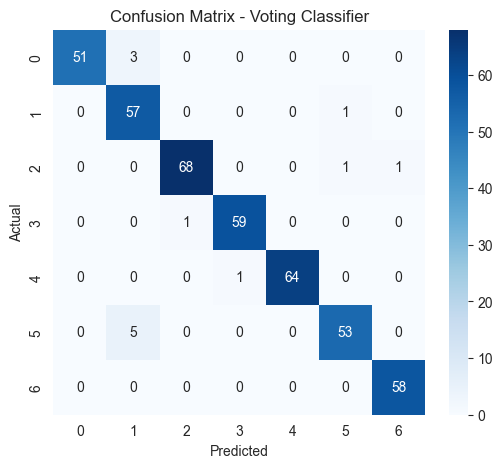

In [16]:
print("\nDetailed TEST Accuracy Report for Voting Classifier:\n")
print(classification_report(y_test, y_test_pred_v))

cm_v = confusion_matrix(y_test, y_test_pred_v)
plt.figure(figsize=(6,5))
sns.heatmap(cm_v, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Voting Classifier')
# plt.savefig('../results/accuracy_figures/confusion_matrices/Voting Classifier Confusion Matrix.png', dpi=300)
plt.show()

# StackingClassifier

In [17]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ('rf', RandomForestClassifier(
        n_estimators=350,
        max_depth=13,
        max_features=0.55,
        min_samples_leaf=1,
        bootstrap=False,
        random_state=42
    )),
    ('xgb', XGBClassifier(
        n_estimators=350,
        max_depth=13,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42,
        use_label_encoder=False
    )),
    ('lgbm', LGBMClassifier()),
]

# Meta learner
meta_model = LogisticRegression()

# Stacking classifier
stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5,
    passthrough=False
)

stack_clf.fit(x_train, y_train)

# Save model
# joblib.dump(stack_clf, "../models/stacking_classifier.pkl")

C:\Users\ratul\PycharmProjects\DWDM_EPJ\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:25:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000258 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1808
[LightGBM] [Info] Number of data points in the train set: 1688, number of used features: 15
[LightGBM] [Info] Start training from score -2.046805
[LightGBM] [Info] Start training from score -1.997578
[LightGBM] [Info] Start training from score -1.792945
[LightGBM] [Info] Start training from score -1.963240
[LightGBM] [Info] Start training from score -1.874472
[LightGBM] [Info] Start training from score -1.984562
[LightGBM] [Info] Start training from score -1.984562
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

C:\Users\ratul\PycharmProjects\DWDM_EPJ\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:25:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ratul\PycharmProjects\DWDM_EPJ\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:25:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ratul\PycharmProjects\DWDM_EPJ\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:25:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ratul\PycharmProjects\DWDM_EPJ\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:25:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1807
[LightGBM] [Info] Number of data points in the train set: 1350, number of used features: 15
[LightGBM] [Info] Start training from score -2.048805
[LightGBM] [Info] Start training from score -1.998374
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.960836
[LightGBM] [Info] Start training from score -1.875141
[LightGBM] [Info] Start training from score -1.987504
[LightGBM] [Info] Start training from score -1.982113
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

,estimators,"[('rf', ...), ('xgb', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,n_estimators,350
,criterion,'gini'
,max_depth,13
,min_samples_split,2


In [18]:
y_train_pred_s = stack_clf.predict(x_train)
y_test_pred_s = stack_clf.predict(x_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_s))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_s))

Training Accuracy: 1.0
Testing Accuracy: 0.966903073286052



Detailed TEST Accuracy Report for Stacking Classifier:

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        54
           1       0.88      0.98      0.93        58
           2       0.99      0.96      0.97        70
           3       0.98      0.98      0.98        60
           4       1.00      0.98      0.99        65
           5       0.96      0.91      0.94        58
           6       0.97      1.00      0.98        58

    accuracy                           0.97       423
   macro avg       0.97      0.97      0.97       423
weighted avg       0.97      0.97      0.97       423



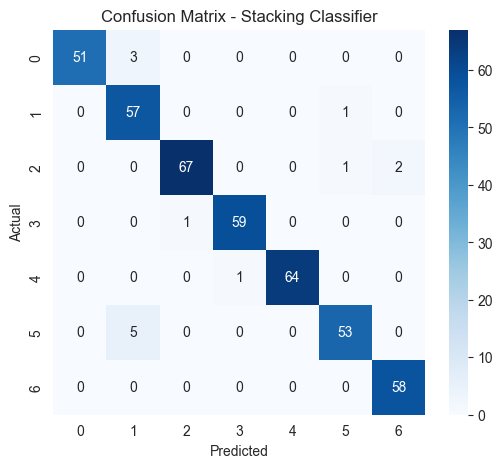

In [19]:
print("\nDetailed TEST Accuracy Report for Stacking Classifier:\n")
print(classification_report(y_test, y_test_pred_s))

cm_s = confusion_matrix(y_test, y_test_pred_s)
plt.figure(figsize=(6,5))
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Stacking Classifier')
# plt.savefig('../results/accuracy_figures/confusion_matrices/Stacking Classifier Confusion Matrix.png', dpi=300)
plt.show()

# Evaluation

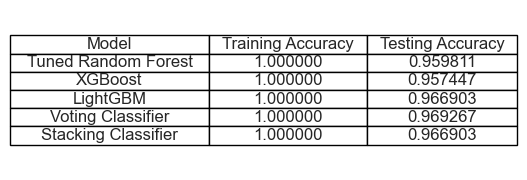

In [20]:
models = [
    'Tuned Random Forest',
    'XGBoost',
    'LightGBM',
    'Voting Classifier',
    'Stacking Classifier'
]

train_accuracies = [
    accuracy_score(y_train, y_train_pred_rf),
    accuracy_score(y_train, y_train_pred_xgb),
    accuracy_score(y_train, y_train_pred_lgbm),
    accuracy_score(y_train, y_train_pred_v),
    accuracy_score(y_train, y_train_pred_s)
]

test_accuracies = [
    accuracy_score(y_test, y_test_pred_rf),
    accuracy_score(y_test, y_test_pred_xgb),
    accuracy_score(y_test, y_test_pred_lgbm),
    accuracy_score(y_test, y_test_pred_v),
    accuracy_score(y_test, y_test_pred_s)
]

summary_train_test = pd.DataFrame({
    'Model': models,
    'Training Accuracy': train_accuracies,
    'Testing Accuracy': test_accuracies
})

# Format the values for display
formatted_data = summary_train_test.copy()
for col in ['Training Accuracy', 'Testing Accuracy']:
    formatted_data[col] = formatted_data[col].apply(lambda x: f"{x:.6f}")


# TABLE VISUALIZATION
fig, ax = plt.subplots(figsize=(5, 0 + len(formatted_data) * 0.38))
ax.axis('off')

table = ax.table(
    cellText=formatted_data.values,
    colLabels=formatted_data.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.auto_set_column_width(col=list(range(len(formatted_data.columns))))

plt.tight_layout()

# plt.savefig('../results/accuracy_figures/Tuned Model Accuracies.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Therefore Voting Classifier Gives Best Results improving from original baseline performance from ~95% to ~97%

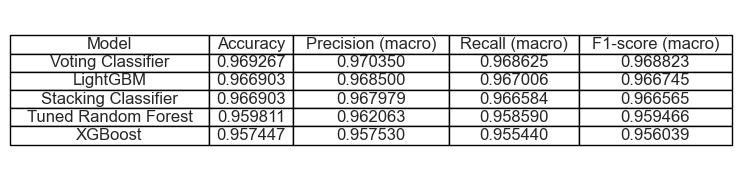

In [27]:
reports = {
    'Tuned Random Forest': classification_report(y_test, y_test_pred_rf, output_dict=True),
    'XGBoost': classification_report(y_test, y_test_pred_xgb, output_dict=True),
    'LightGBM': classification_report(y_test, y_test_pred_lgbm, output_dict=True),
    'Voting Classifier': classification_report(y_test, y_test_pred_v, output_dict=True),
    'Stacking Classifier': classification_report(y_test, y_test_pred_s, output_dict=True)
}
summary_data = []
for model_name, report in reports.items():
    summary_data.append({
        'Model': model_name,
        'Accuracy': report['accuracy'],
        'Precision (macro)': report['macro avg']['precision'],
        'Recall (macro)': report['macro avg']['recall'],
        'F1-score (macro)': report['macro avg']['f1-score']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values(by='F1-score (macro)', ascending=False).reset_index(drop=True)

formatted_data = summary_df.copy()
for col in ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-score (macro)']:
    formatted_data[col] = formatted_data[col].apply(lambda x: f"{x:.6f}")

fig, ax = plt.subplots(figsize=(7.25, 0 + len(formatted_data)*0.38))
ax.axis('off')

table = ax.table(
    cellText=formatted_data.values,
    colLabels=formatted_data.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.auto_set_column_width(col=list(range(len(formatted_data.columns))))

plt.tight_layout()
plt.savefig('../results/accuracy_figures/Model Comparisons C.png', dpi=300)
plt.show()

# **Final Plots (base models + best model)**

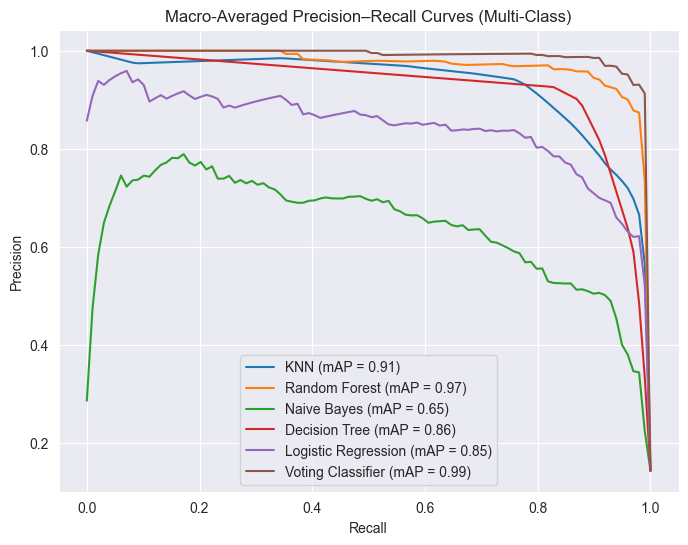

In [28]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

test_data = pd.read_csv('../data/processed/test.csv')

y_test = test_data['NObeyesdad']
x_test = test_data.drop('NObeyesdad', axis=1)

dt_model = joblib.load('../models/decision_tree_model.pkl')
knn = joblib.load('../models/knn_model.pkl')
lr_model = joblib.load('../models/logistic_regression_model.pkl')
nb_model = joblib.load('../models/naive_bayes_model.pkl')
rf_model = joblib.load('../models/random_forest_model.pkl')
vt_model = joblib.load('../models/voting_classifier_(BEST_MODEL).pkl')

classes = np.unique(y_test)
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)

y_test_proba_knn = knn.predict_proba(x_test)
y_test_proba_rf = rf_model.predict_proba(x_test)
y_test_proba_nb = nb_model.predict_proba(x_test)
y_test_proba_dt = dt_model.predict_proba(x_test)
y_test_proba_lr = lr_model.predict_proba(x_test)
y_test_proba_vt = vt_model.predict_proba(x_test)

models = {
    'KNN': y_test_proba_knn,
    'Random Forest': y_test_proba_rf,
    'Naive Bayes': y_test_proba_nb,
    'Decision Tree': y_test_proba_dt,
    'Logistic Regression': y_test_proba_lr,
    'Voting Classifier': y_test_proba_vt
}

plt.figure(figsize=(8, 6))

for name, proba in models.items():
    precision = dict()
    recall = dict()
    avg_precision = dict()

    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], proba[:, i])
        avg_precision[i] = average_precision_score(y_test_bin[:, i], proba[:, i])

    # Compute macro-average across classes
    all_precision = np.linspace(0, 1, 100)
    mean_recall = np.zeros_like(all_precision)

    for i in range(n_classes):
        mean_recall += np.interp(all_precision, recall[i][::-1], precision[i][::-1])
    mean_recall /= n_classes

    macro_avg_precision = np.mean(list(avg_precision.values()))
    plt.plot(all_precision, mean_recall, label=f'{name} (mAP = {macro_avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Macro-Averaged Precision–Recall Curves (Multi-Class)')
plt.legend()
plt.grid(True)
plt.savefig('../results/accuracy_figures/Precision-Recall Curves.png', dpi=300)
plt.show()

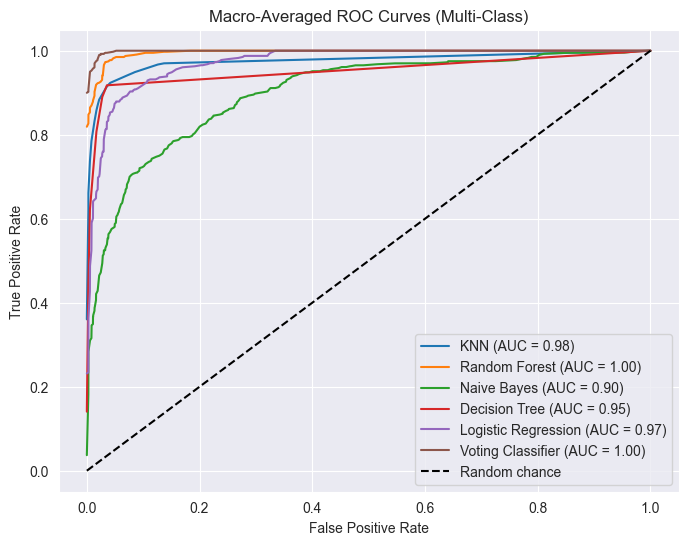

In [29]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

plt.figure(figsize=(8, 6))

for name, proba in models.items():
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Compute ROC curve and AUC for each class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute macro-average ROC curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes

    # Compute macro-average AUC
    macro_roc_auc = roc_auc_score(y_test_bin, proba, average='macro')

    plt.plot(all_fpr, mean_tpr, label=f'{name} (AUC = {macro_roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Averaged ROC Curves (Multi-Class)')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('../results/accuracy_figures/ROC Curves.png', dpi=300)
plt.show()